In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [52]:
dataset = pd.read_csv("HTRU_2.csv")
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [53]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [54]:
print(X_train)

[[ 1.04109375e+02  3.31980879e+01  3.55939152e-01 ...  1.93184115e+01
   7.47060784e+00  6.76837364e+01]
 [ 2.70390625e+01  3.37547224e+01  4.77912374e+00 ...  7.88154399e+01
  -3.48492115e-01 -8.93790697e-01]
 [ 8.02968750e+01  3.72494462e+01  5.86412649e-01 ...  1.92181317e+01
   8.46112943e+00  7.63715586e+01]
 ...
 [ 1.22023438e+02  5.14129217e+01  3.01448990e-02 ...  2.20206823e+01
   7.60177956e+00  6.17951477e+01]
 [ 1.17039062e+02  6.89160951e+01  4.96720100e-03 ...  9.62136739e+01
   6.32783665e-01 -1.41328597e+00]
 [ 1.21203125e+02  4.17816795e+01  2.60014525e-01 ...  2.33998119e+01
   6.66951992e+00  4.93686310e+01]]


In [55]:
print(X_test)

[[ 9.86875000e+01  4.39144676e+01  5.52936762e-01 ...  1.45343162e+01
   8.57575802e+00  1.00703242e+02]
 [ 1.01921875e+02  4.57369533e+01  3.63985257e-01 ...  2.17222851e+01
   7.06403100e+00  5.67506024e+01]
 [ 1.11296875e+02  3.80785289e+01  2.96122476e-01 ...  1.29144919e+01
   1.30788624e+01  2.03978636e+02]
 ...
 [ 1.01929688e+02  4.64800333e+01  4.25094987e-01 ...  1.29235470e+01
   1.63649090e+01  2.76722213e+02]
 [ 1.19445312e+02  5.31430570e+01  1.28302730e-02 ...  1.79297569e+01
   8.28988851e+00  8.13465166e+01]
 [ 1.16679688e+02  4.74069704e+01  6.94263630e-02 ...  8.26920169e+01
  -1.92942742e-01 -1.87714766e+00]]


In [56]:
print(y_train)

[0 1 0 ... 0 0 0]


In [57]:
print(y_test)

[0 0 0 ... 1 0 0]


In [58]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [59]:
print(X_train)

[[-0.26251975 -1.93595361 -0.12144824 ... -0.36064647 -0.18454224
  -0.35151653]
 [-3.24433077 -1.85502251  3.98813482 ...  2.68005857 -1.91855563
  -0.99800321]
 [-1.18381321 -1.34691204  0.0926848  ... -0.36577145  0.03512214
  -0.26961563]
 ...
 [ 0.43056618  0.71236664 -0.42414385 ... -0.22254195 -0.15545276
  -0.4070288 ]
 [ 0.23772326  3.25721603 -0.44753646 ...  3.56922731 -1.70094167
  -1.00290054]
 [ 0.39882871 -0.68795433 -0.21057186 ... -0.152059   -0.3621966
  -0.52417472]]


In [60]:
print(X_test)

[[-4.72289322e-01 -3.77860579e-01  6.15823355e-02 ... -6.05146460e-01
   6.05429028e-02 -4.02385991e-02]
 [-3.47153005e-01 -1.12882832e-01 -1.13972604e-01 ... -2.37792089e-01
  -2.74707307e-01 -4.54584192e-01]
 [ 1.55609568e-02 -1.22636872e+00 -1.77023949e-01 ... -6.87930557e-01
   1.05918001e+00  9.33348074e-01]
 ...
 [-3.46850743e-01 -4.84375702e-03 -5.71955229e-02 ... -6.87467782e-01
   1.78791462e+00  1.61910849e+00]
 [ 3.30819842e-01  9.63917249e-01 -4.40230879e-01 ... -4.31616218e-01
  -2.85333963e-03 -2.22716237e-01]
 [ 2.23819223e-01  1.29926960e-01 -3.87647423e-01 ...  2.87817817e+00
  -1.88406001e+00 -1.00727340e+00]]


In [61]:
print(y_train.shape)
print(type(y_train))

(13422,)
<class 'numpy.ndarray'>


In [62]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf' ,random_state = 0)
classifier.fit(X_train,y_train)

SVC(random_state=0)

In [63]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 1]
 [0 0]
 [0 0]]


In [64]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[4070   26]
 [  66  313]]


0.9794413407821229

For visualization purpose only the below code has been done:

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [66]:
from sklearn.svm import SVC

classifier_pca = SVC(kernel='rbf', random_state=0)
classifier_pca.fit(X_train_pca, y_train)

SVC(random_state=0)

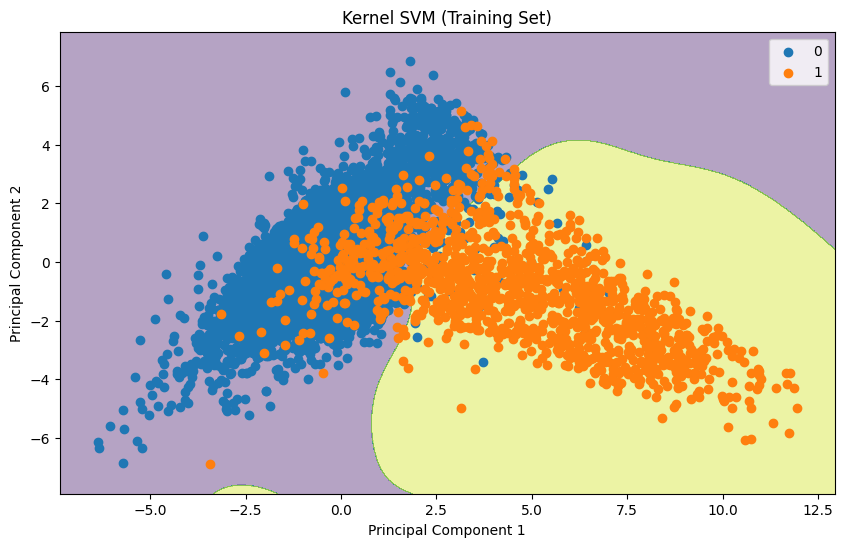

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_set, y_set = X_train_pca, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
)

plt.figure(figsize=(10,6))

plt.contourf(
    X1, X2,
    classifier_pca.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.4
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        label=j
    )

plt.title('Kernel SVM (Training Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

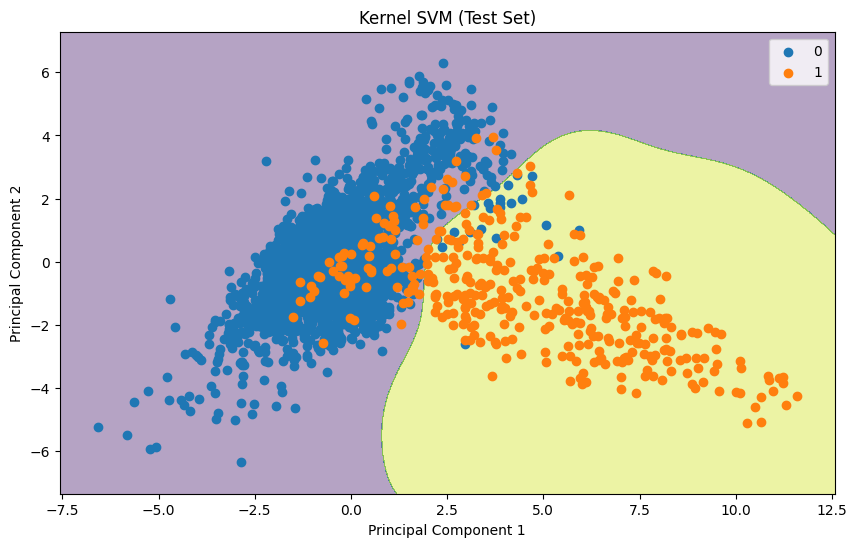

In [50]:
X_set, y_set = X_test_pca, y_test

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
)

plt.figure(figsize=(10,6))

plt.contourf(
    X1, X2,
    classifier_pca.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.4
)

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        label=j
    )

plt.title('Kernel SVM (Test Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()